# Causal Discovery and Causal Feature Selection for Robust Prediction

This tutorial walks through the key ideas and algorithms at the intersection of causal inference and robust machine learning.
The tutorial is structured as follows:

1. **Pairwise causal discovery** — can we tell which variable causes which, from observational data alone?
2. **Multivariate causal discovery** — recovering the full causal graph over many variables
3. **Multivariate causal feature selection** — finding the Markov Blanket of a target variable
4. **CFS for robust prediction** — why causal parents are more stable predictors than correlated features
5. **Invariant Causal Predictors** — a principled method to find invariant features across environments

In [1]:
import os
if not os.path.exists('zh03-causal-discovery-robust-predictions'):
    !git clone https://github.com/WinterSchool2026/zh03-causal-discovery-robust-predictions.git
import sys
sys.path.insert(0, 'zh03-causal-discovery-robust-predictions')

In [2]:
# Standard library
import time

# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# Custom modules / Causal discovery
from src.causal_feature_selection import (
    hiton_mb, iamb, mmpc, mb_ges, resit_mb, hiton_pc
)

from src.linGAM import *

# Data generation
from src.generate_scm import *

np.random.seed(3)

LinGAM backend in use: causal-learn


---
## Section 4 — CFS for Robust Prediction

### 4.1 The distribution shift problem

Standard machine learning optimizes for expected loss on training data. In deployment, the distribution may shift. We focus here on **intervention shifts**: an external manipulation forces a variable to a particular value, breaking its natural causal mechanism.

Formally, an intervention $do(X_i = x)$ replaces the structural equation for $X_i$, which propagates to all downstream variables. We want to understand which predictors of Y remain reliable after such interventions?

### 4.2 Why standard predictors degrade

Consider a graph where $A → Y ← B → C$. Under the training distribution, $C$ correlates with $Y$ via $B$, and a full regression on $(A, B, C)$ will assign weight to $C$. But if we intervene on $B$, the $B → C$ edge is broken. $C$ no longer tracks Y the way it did in training. The predictor breaks.

The structural equation for Y is:

$$Y = f(\text{PA}(Y), \varepsilon_Y)$$

This equation is **invariant** to interventions on any variable other than Y itself. Parents of Y are therefore the most robust feature set.

However this set is sometimes **over conservative**. Especially children in causal graph might be very predictive of their parents and if we don't expect the relationship between the target variable and its children to break at test time, then we should use the precious information they contain about the target. A very useful set of variable for this is the Markov Blanket (MB) as the rest of the variables are independent of the target conditioned on the markov blanket. It is thus the smallest set of variables that has optimal predicitve power under no distribution shift. By having a restricted number of variables it is also robust to a large range of interventions (outside of the MB).

### 4.3 Setup: SCM with `generate_dag`

We use `generate_dag` and `fit_from_adjacency` to build a controlled SCM, then track which nodes are parents, children, spouses, and unrelated ("others") with respect to Y.


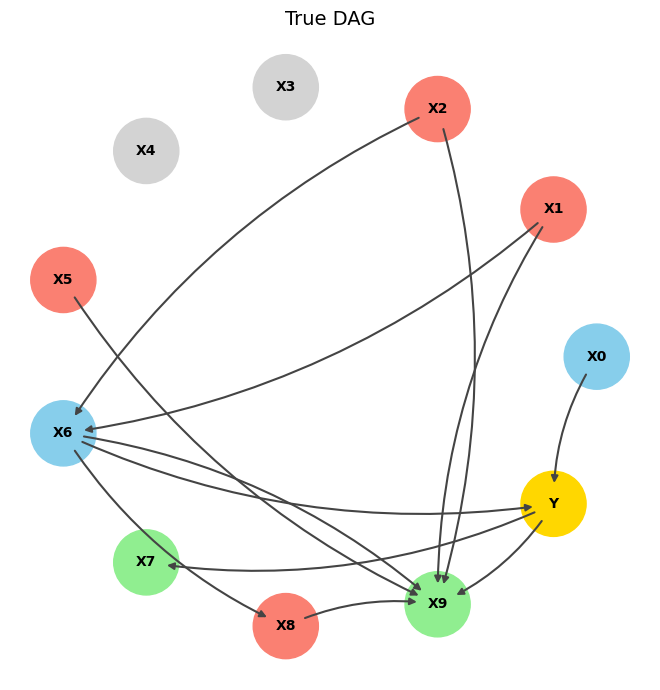

Parents of Y:  [np.int64(0), np.int64(6)]
Children of Y: [np.int64(7), np.int64(9)]
Spouses of Y:  [np.int64(1), np.int64(2), np.int64(5), np.int64(6), np.int64(8)]
Others:        [np.int64(3), np.int64(4)]


In [3]:
# Build SCM from an explicit random DAG
d = 10
scm = SCMGenerator(d=d)
A = generate_dag(num_vars=d+1, n_parents=2, n_children=2, n_spouses=1, sparsity=0.15)
scm.fit_from_adjacency(A, Y_idx=d, noise_type='uniform', is_linear=True)

col_names = np.hstack((np.array([f'X{i}' for i in range(scm.n_nodes-1)]), np.array(['Y'])))
plot_graphs_from_adj([scm.A], [d], [col_names], ['True DAG'])

print("Parents of Y: ", sorted(scm.parents_idx))
print("Children of Y:", sorted(scm.children_idx))
print("Spouses of Y: ", sorted(scm.spouses_idx))
print("Others:       ", sorted(scm.others_idx))


In [4]:
# Sample observational data and run CFS algorithms
data = scm.sample(n_samples=1000)
data.head()


,X0,X1,X2,X3,X4,X5,X6,X7,X8,X9,Y
0,0.708461,-0.924875,0.822486,0.963810,-0.430024,-0.976274,-1.442023,-2.245838,-1.755258,-3.651343,2.037368
1,0.938858,-0.794474,-0.522490,-0.474379,-0.166540,0.272819,-0.089797,-1.016533,0.063606,-2.376719,1.313201
2,0.440302,-0.453658,-0.747037,0.827803,-0.249947,-0.049815,0.640093,0.015862,0.825808,-1.351181,-0.091342
3,-0.179817,-0.822484,0.156677,-0.619895,-0.739584,-0.804778,-0.886884,-0.701682,-0.613860,-2.060563,0.785153
4,-0.721647,0.558378,-0.098967,0.519634,0.210759,0.895381,0.885373,1.390193,0.838902,2.569561,-1.385583


In [5]:
# Run several MB/CFS algorithms on the observational data
# ------------------------------------------------------------

# HITON-MB
start = time.time()
mb_hiton = hiton_mb(data, 'Y', alpha=0.05, ci_method='partial')
print(f"HITON-MB  : {time.time()-start:.2f}s  ->  {sorted(mb_hiton)}")

# HITON-PC  (parents + children only, no spouses)
start = time.time()
mb_hiton_pc = hiton_pc(data, 'Y', alpha=0.05, ci_method='partial')
print(f"HITON-PC  : {time.time()-start:.2f}s  ->  {sorted(mb_hiton_pc)}")

# IAMB
start = time.time()
mb_iamb = iamb(data, 'Y', alpha=0.05, ci_method='partial')
print(f"IAMB      : {time.time()-start:.2f}s  ->  {sorted(mb_iamb)}")

# MB-GES
start = time.time()
mb_ges_result = mb_ges(data, 'Y')
print(f"MB-GES    : {time.time()-start:.2f}s  ->  {sorted(mb_ges_result)}")

# RESIT-MB (also returns estimated parents)
start = time.time()
mb_resit, parents_resit = resit_mb(data, 'Y', alpha=0.05, return_parents=True)
print(f"RESIT-MB  : {time.time()-start:.2f}s  ->  {sorted(mb_resit)}")
print(f"  RESIT parents: {sorted(parents_resit)}")

true_mb = set(scm.parents_idx) | set(scm.children_idx) | set(scm.spouses_idx)
print(f"\nTrue MB:    {sorted(true_mb)}")
print(f"True parents: {sorted(scm.parents_idx)}")


HITON-MB  : 2.17s  ->  ['X0', 'X1', 'X2', 'X6', 'X7', 'X9']
HITON-PC  : 0.62s  ->  ['X0', 'X6', 'X7', 'X9']
IAMB      : 0.59s  ->  ['X0', 'X1', 'X2', 'X5', 'X6', 'X7', 'X8', 'X9']
MB-GES    : 0.44s  ->  ['X0', 'X1', 'X2', 'X5', 'X6', 'X7', 'X8', 'X9']
RESIT-MB  : 1.05s  ->  ['X3', 'X4']
  RESIT parents: []

True MB:    [np.int64(0), np.int64(1), np.int64(2), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
True parents: [np.int64(0), np.int64(6)]


### 4.4 Robustness under intervention: MB vs full predictor

We now compare two predictors:
- **Full predictor**: trained on all features
- **MB predictor**: trained on the MB-GES estimated feature set

We evaluate both as we sweep the intervention value on each group of nodes (parents, children, spouses, others). This produces R² curves as a function of intervention strength.

The design reveals something important: different groups of nodes have different effects on the predictor when intervened on.


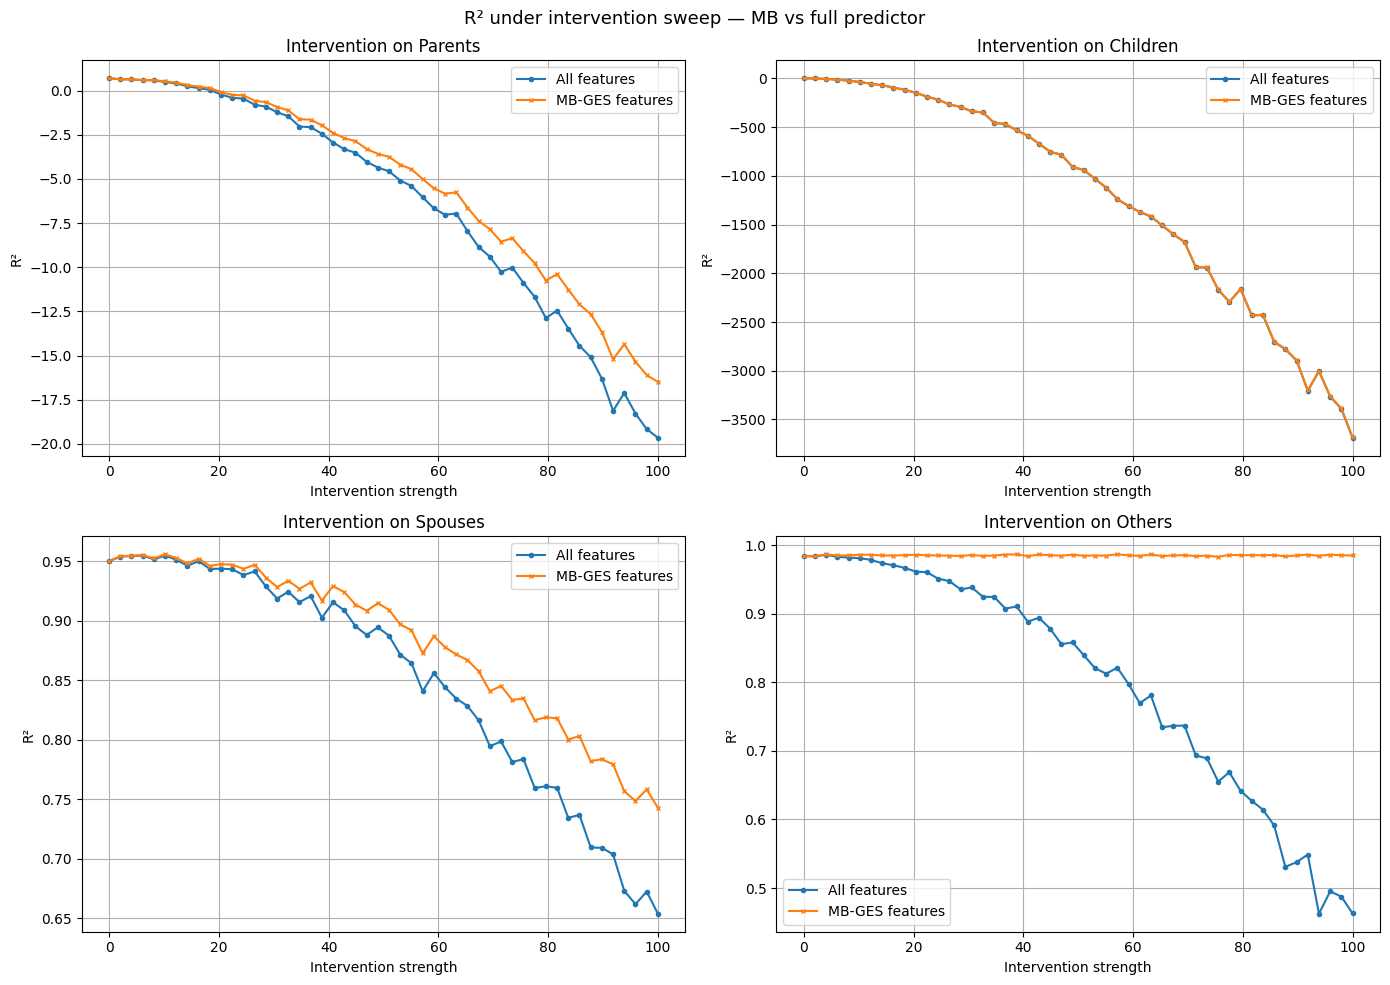

In [6]:
# Fit predictors on observational data
lr_full = LinearRegression().fit(data.drop(columns='Y').values, data['Y'].values)
lr_ges  = LinearRegression().fit(data[mb_ges_result].values, data['Y'].values)

# Sweep intervention values across node groups
intervention_values = np.linspace(0, 100, 50)

intervention_groups = {
    'Parents':  scm.parents_idx,
    'Children': scm.children_idx,
    'Spouses':  scm.spouses_idx,
    'Others':   scm.others_idx
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (group_name, indices) in enumerate(intervention_groups.items()):
    r2_full, r2_ges = [], []
    indices_list = list(indices)

    for val in intervention_values:
        scm_int = scm.intervention(indices=indices_list, values=[val]*len(indices_list))
        data_int = scm_int.sample(n_samples=1000)

        r2_full.append(lr_full.score(data_int.drop(columns='Y').values, data_int['Y'].values))
        r2_ges.append(lr_ges.score(data_int[mb_ges_result].values, data_int['Y'].values))

    axes[i].plot(intervention_values, r2_full, label='All features', marker='o', markersize=3)
    axes[i].plot(intervention_values, r2_ges,  label='MB-GES features', marker='x', markersize=3)
    axes[i].set_title(f'Intervention on {group_name}')
    axes[i].set_xlabel('Intervention strength')
    axes[i].set_ylabel('R²')
    axes[i].grid(True)
    axes[i].legend()

plt.suptitle('R² under intervention sweep — MB vs full predictor', fontsize=13)
plt.tight_layout()
plt.show()


### 4.5 Using HITON-PC: parents and children

HITON-PC returns only the parents and children of Y (the PC set), not spouses. Since spouses are not parents of Y, they don't appear in Y's structural equation. The HITON-PC set is a subset of the MB that sits closer to the true causal mechanism.

Let's repeat the experiment with HITON-PC features.


HITON-PC features: ['X0', 'X6', 'X7', 'X9']
True parents:      [np.int64(0), np.int64(6)]
True PC set:       [np.int64(0), np.int64(6), np.int64(7), np.int64(9)]


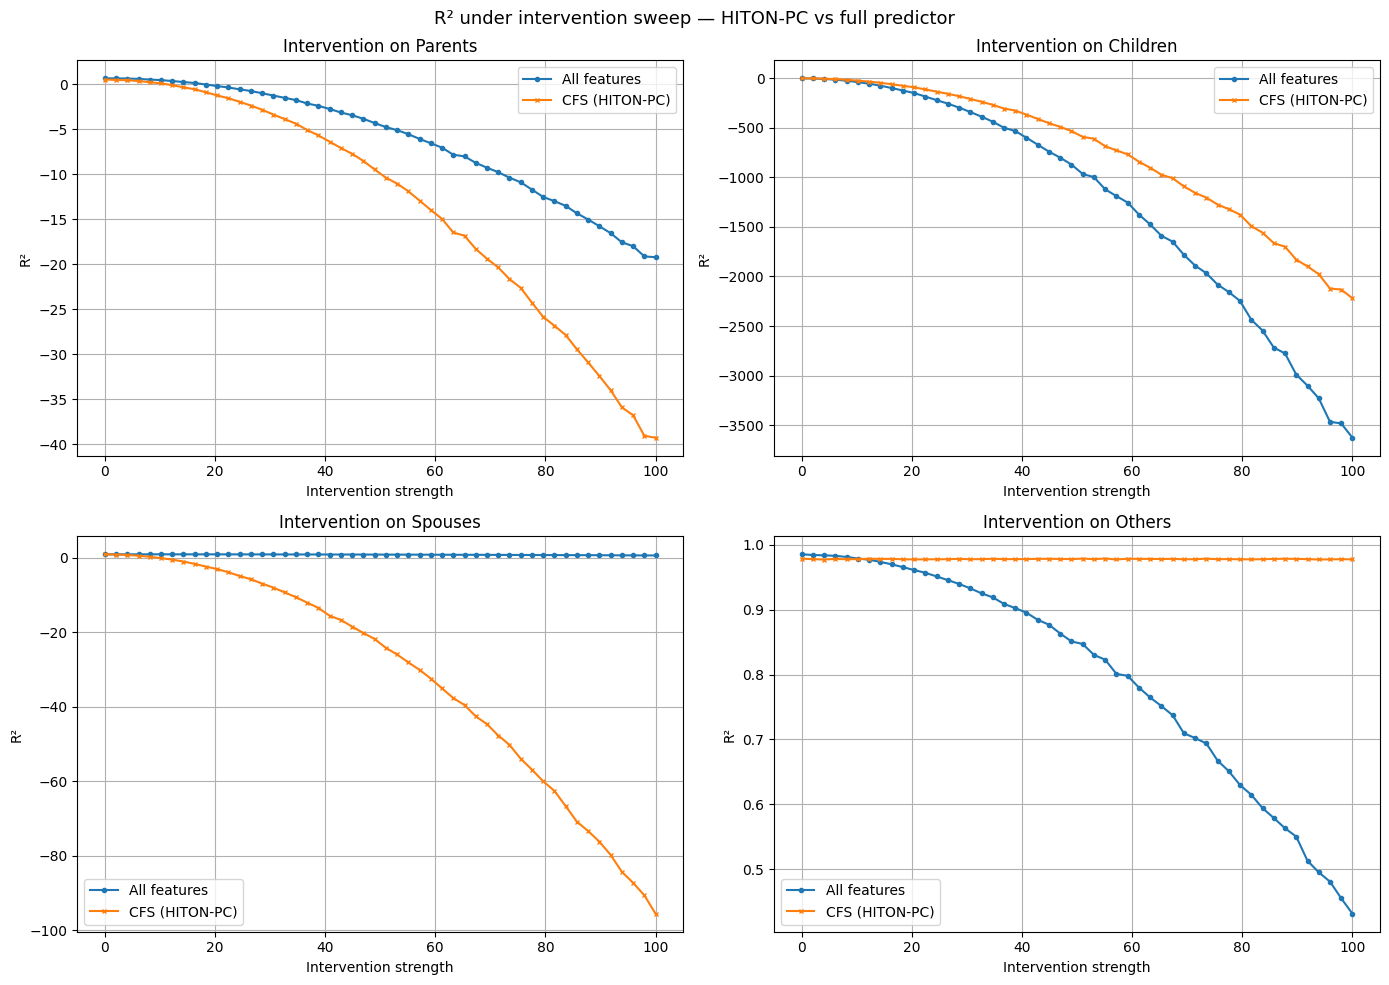

In [7]:
# Fit a predictor on HITON-PC features
lr_pc = LinearRegression().fit(data[mb_hiton_pc].values, data['Y'].values)

print(f"HITON-PC features: {sorted(mb_hiton_pc)}")
print(f"True parents:      {sorted(scm.parents_idx)}")
print(f"True PC set:       {sorted(set(scm.parents_idx) | set(scm.children_idx))}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (group_name, indices) in enumerate(intervention_groups.items()):
    r2_full, r2_pc = [], []
    indices_list = list(indices)

    for val in intervention_values:
        scm_int = scm.intervention(indices=indices_list, values=[val]*len(indices_list))
        data_int = scm_int.sample(n_samples=10000)

        r2_full.append(lr_full.score(data_int.drop(columns='Y').values, data_int['Y'].values))
        r2_pc.append(lr_pc.score(data_int[mb_hiton_pc].values, data_int['Y'].values))

    axes[i].plot(intervention_values, r2_full, label='All features', marker='o', markersize=3)
    axes[i].plot(intervention_values, r2_pc,   label='CFS (HITON-PC)', marker='x', markersize=3)
    axes[i].set_title(f'Intervention on {group_name}')
    axes[i].set_xlabel('Intervention strength')
    axes[i].set_ylabel('R²')
    axes[i].grid(True)
    axes[i].legend()

plt.suptitle('R² under intervention sweep — HITON-PC vs full predictor', fontsize=13)
plt.tight_layout()
plt.show()


---
## Section 4.6 — LinGAM on the HITON-PC subgraph: orienting edges to isolate parents

### The gap left by HITON-PC

HITON-PC returns the **Parents and Children (PC)** of Y — a smaller set than the full Markov Blanket (spouses are excluded) and directly adjacent to Y in the causal graph. The problem: HITON-PC is a **constraint-based** method. It uses conditional independence tests to decide *which* variables are adjacent to Y, but it cannot tell *which direction* those edges point.

From a robustness standpoint the direction matters:

- **Parents** appear in Y's structural equation. A predictor using only parents is invariant to any intervention on variables other than Y itself.
- **Children** are correlated with Y observationally, but that correlation breaks the moment we intervene on Y or on the children themselves.

### LinGAM to the rescue

**LiNGAM** (Linear Non-Gaussian Acyclic Model, Shimizu et al. 2006) can identify causal directions from observational data alone — something impossible under Gaussian noise. The key insight: in a linear SCM with at least one non-Gaussian noise term, the causal direction is the *only* one for which the source variable and the residual are independent.

**DirectLiNGAM** (Shimizu et al. 2011) implements this efficiently:
1. Among remaining variables, find the one whose residual (after linearly projecting out all others) is **most non-Gaussian** — that variable is the most exogenous and is placed first in the causal order.
2. Regress it out of all remaining variables and repeat.
3. Once the full causal order is known, prune small OLS coefficients to recover the sparse graph.

We apply it **restricted to the HITON-PC subgraph** (PC set + Y). This is smaller and more focused than running LinGAM on all variables.

> **Note on sample size.** The SCM uses uniform noise — non-Gaussian but mildly so. DirectLiNGAM needs enough samples to estimate negentropy reliably, so we resample **n = 5 000** from the same SCM for the LinGAM step (the predictors are still fit on the original n = 1 000).


In [8]:
# Resample at n=5 000 from the same SCM for a stable negentropy estimate
data_lingam = scm.sample(n_samples=5000)

pc_cols   = sorted(mb_hiton_pc)           # parents + children from HITON-PC
df_pc_sub = data_lingam[pc_cols + ['Y']]  # subgraph: PC set + target

causal_order, B_lingam, parents_lingam = direct_lingam(df_pc_sub, 'Y', threshold=0.10)

print('=' * 55)
print('DirectLiNGAM results on the HITON-PC subgraph')
print('=' * 55)
print(f'Input (HITON-PC set) : {pc_cols}')
print(f'Inferred causal order: {causal_order}')
print()
print(f'LinGAM parents of Y  : {sorted(parents_lingam)}')
print(f'True   parents of Y  : {sorted([f"X{i}" for i in scm.parents_idx])}')
print(f'True   children of Y : {sorted([f"X{i}" for i in scm.children_idx])}')


DirectLiNGAM results on the HITON-PC subgraph
Input (HITON-PC set) : ['X0', 'X6', 'X7', 'X9']
Inferred causal order: ['X0', 'X9', 'X6', 'Y', 'X7']

LinGAM parents of Y  : ['X0', 'X6']
True   parents of Y  : ['X0', 'X6']
True   children of Y : ['X7', 'X9']


### Step 5 — Visualise the B matrix and the inferred subgraph

The **B matrix** is lower-triangular in the inferred causal order: `B[i, j] ≠ 0` means variable `j` directly causes variable `i`. The right panel shows the inferred edge directions, colour-coded green (LinGAM says → parent) and red (LinGAM says → child).


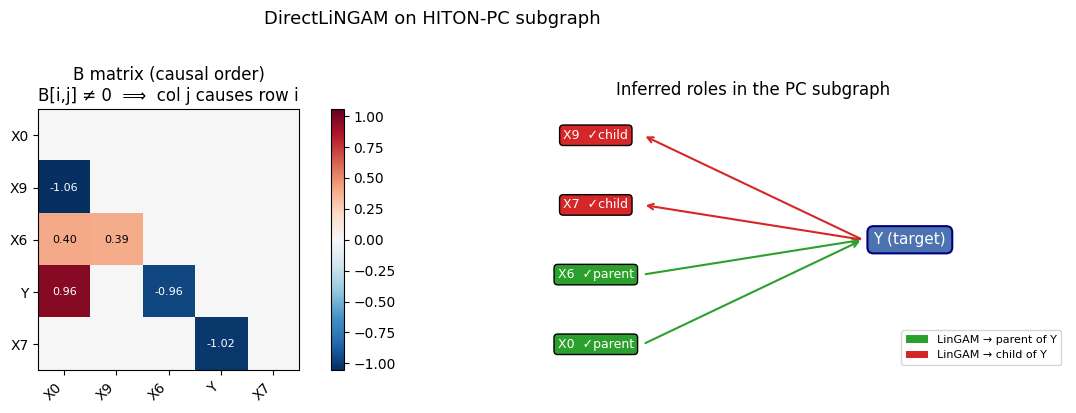

In [9]:
all_cols = pc_cols + ['Y']
p_sub    = len(all_cols)

# Reorder B into causal order for a clean lower-triangular display
order_idx   = [all_cols.index(v) for v in causal_order]
B_reordered = B_lingam[np.ix_(order_idx, order_idx)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Left: B matrix heatmap ───────────────────────────────────────────────
vmax = max(np.abs(B_reordered).max(), 1e-3)
im   = axes[0].imshow(B_reordered, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[0].set_xticks(range(p_sub)); axes[0].set_xticklabels(causal_order, rotation=45, ha='right')
axes[0].set_yticks(range(p_sub)); axes[0].set_yticklabels(causal_order)
axes[0].set_title('B matrix (causal order)\nB[i,j] ≠ 0  ⟹  col j causes row i')
plt.colorbar(im, ax=axes[0])
for i in range(p_sub):
    for j in range(p_sub):
        if B_reordered[i, j] != 0:
            axes[0].text(j, i, f'{B_reordered[i,j]:.2f}', ha='center', va='center',
                         fontsize=8, color='white' if abs(B_reordered[i,j]) > 0.5 else 'black')

# ── Right: inferred subgraph (annotated with true roles) ─────────────────
ax = axes[1]
ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, p_sub - 0.5); ax.axis('off')
ax.set_title('Inferred roles in the PC subgraph', pad=10)

y_node_pos          = (p_sub - 1) / 2.0
true_parents_names  = [f'X{i}' for i in scm.parents_idx]

ax.annotate('Y (target)', xy=(1, y_node_pos),
            bbox=dict(boxstyle='round,pad=0.4', fc='#4C72B0', ec='navy', lw=1.5),
            color='white', fontsize=11, ha='center', va='center')

for k, var in enumerate(pc_cols):
    y_pos    = k * (p_sub - 1) / max(len(pc_cols) - 1, 1)
    is_par   = var in parents_lingam
    fc       = '#2ca02c' if is_par else '#d62728'
    role_tag = '✓parent' if var in true_parents_names else '✓child'
    ax.annotate(f'{var}  {role_tag}', xy=(0, y_pos),
                bbox=dict(boxstyle='round,pad=0.3', fc=fc, ec='black', lw=1),
                color='white', fontsize=9, ha='center', va='center')
    if is_par:
        ax.annotate('', xy=(0.85, y_node_pos), xytext=(0.15, y_pos),
                    arrowprops=dict(arrowstyle='->', color='#2ca02c', lw=1.5))
    else:
        ax.annotate('', xy=(0.15, y_pos), xytext=(0.85, y_node_pos),
                    arrowprops=dict(arrowstyle='->', color='#d62728', lw=1.5))

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#2ca02c', label='LinGAM → parent of Y'),
    Patch(facecolor='#d62728', label='LinGAM → child of Y'),
], loc='lower right', fontsize=8)

plt.suptitle('DirectLiNGAM on HITON-PC subgraph', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---
## Section 4.7 — Robustness of the LinGAM-parents predictor

We now train one predictor per feature set and compare their R² curves under the same intervention sweep as before.

**Expected behaviour**

| Feature set | Parents intervened | Children intervened | Spouses intervened | Others intervened |
|---|:---:|:---:|:---:|:---:|
| All features | ✗ degrades | ✗ degrades | ✗ degrades | ✓ stable |
| MB-GES | ✗ degrades | ✗ degrades | ✓ stable | ✓ stable |
| HITON-PC | ✗ degrades | ✗ degrades | ✓ stable | ✓ stable |
| **LinGAM-parents** | **✗ degrades** | **✓ stable** | **✓ stable** | **✓ stable** |

LinGAM-parents is the **only purely observational method** expected to be stable under child interventions, because it is the only one that discards children from the feature set.


In [10]:
# Fit one predictor per feature set on the original n=1 000 sample
lingam_parent_cols = parents_lingam

lr_full   = LinearRegression().fit(data.drop(columns='Y').values, data['Y'].values)
lr_ges    = LinearRegression().fit(data[mb_ges_result].values,    data['Y'].values)
lr_pc     = LinearRegression().fit(data[mb_hiton_pc].values,      data['Y'].values)
lr_lingam = LinearRegression().fit(data[lingam_parent_cols].values, data['Y'].values)

print('Feature sets')
print(f'  All features   : {sorted(data.drop(columns="Y").columns.tolist())}')
print(f'  MB-GES         : {sorted(mb_ges_result)}')
print(f'  HITON-PC       : {sorted(mb_hiton_pc)}')
print(f'  LinGAM-parents : {sorted(lingam_parent_cols)}')

# Observational R² (no intervention)
print('\nObservational R² (training distribution)')
print(f'  All features   : {lr_full.score(data.drop(columns="Y").values, data["Y"].values):.3f}')
print(f'  MB-GES         : {lr_ges.score(data[mb_ges_result].values, data["Y"].values):.3f}')
print(f'  HITON-PC       : {lr_pc.score(data[mb_hiton_pc].values, data["Y"].values):.3f}')
print(f'  LinGAM-parents : {lr_lingam.score(data[lingam_parent_cols].values, data["Y"].values):.3f}')


Feature sets
  All features   : ['X0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9']
  MB-GES         : ['X0', 'X1', 'X2', 'X5', 'X6', 'X7', 'X8', 'X9']
  HITON-PC       : ['X0', 'X6', 'X7', 'X9']
  LinGAM-parents : ['X0', 'X6']

Observational R² (training distribution)
  All features   : 0.986
  MB-GES         : 0.986
  HITON-PC       : 0.980
  LinGAM-parents : 0.955


### Intervention sweep

We sweep each intervention group from 0 to 100 and record R² for each predictor. The key panel to watch is **Intervention on Children** — that is where LinGAM-parents should stay flat while the other methods drop.


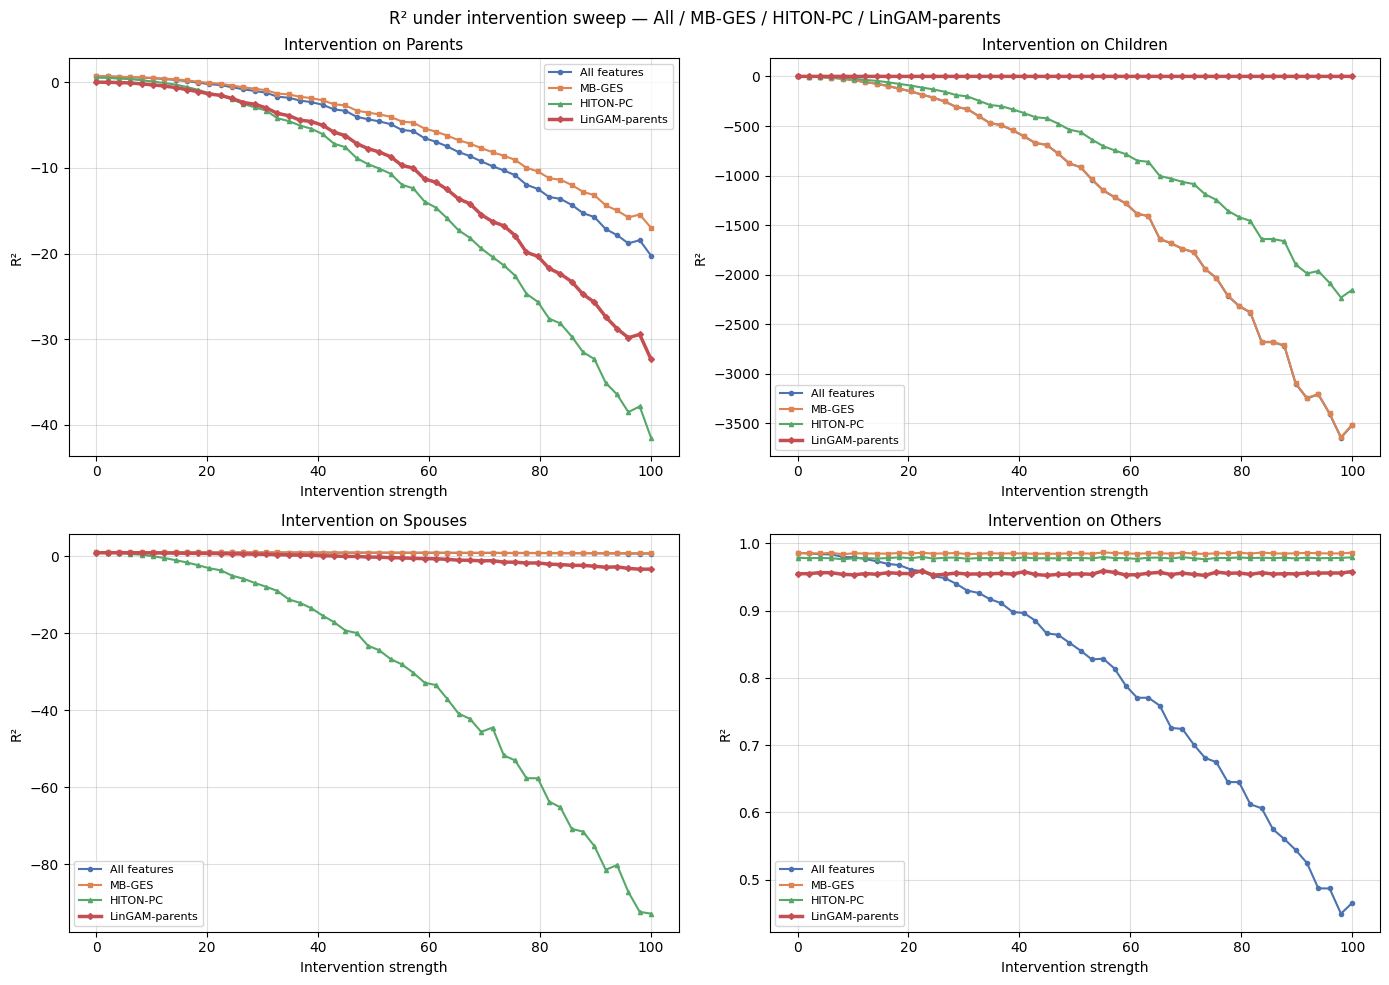

In [11]:
intervention_values = np.linspace(0, 100, 50)

predictor_styles = {
    'All features':   (lr_full,   lambda d: d.drop(columns='Y').values, '#4C72B0', 'o', 1.5),
    'MB-GES':         (lr_ges,    lambda d: d[mb_ges_result].values,     '#DD8452', 's', 1.5),
    'HITON-PC':       (lr_pc,     lambda d: d[mb_hiton_pc].values,       '#55A868', '^', 1.5),
    'LinGAM-parents': (lr_lingam, lambda d: d[lingam_parent_cols].values,'#C44E52', 'D', 2.5),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax_i, (group_name, indices) in enumerate(intervention_groups.items()):
    idx_list = list(indices)
    r2_scores = {label: [] for label in predictor_styles}

    for val in intervention_values:
        scm_int = scm.intervention(indices=idx_list, values=[val] * len(idx_list))
        d_int   = scm_int.sample(n_samples=2000)
        for label, (model, get_X, *_) in predictor_styles.items():
            r2_scores[label].append(model.score(get_X(d_int), d_int['Y'].values))

    ax = axes[ax_i]
    for label, (_, _, color, marker, lw) in predictor_styles.items():
        ax.plot(intervention_values, r2_scores[label],
                label=label, color=color, marker=marker,
                markersize=3, linewidth=lw,
                zorder=3 if label == 'LinGAM-parents' else 2)
    ax.set_title(f'Intervention on {group_name}', fontsize=11)
    ax.set_xlabel('Intervention strength')
    ax.set_ylabel('R²')
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=8)

plt.suptitle('R² under intervention sweep — All / MB-GES / HITON-PC / LinGAM-parents',
             fontsize=12)
plt.tight_layout()
plt.show()


### Summary table — R² at high intervention strength

A single snapshot at intervention = 80 makes the robustness differences easy to read at a glance. Green = high R² (robust), red = low R² (broken).


In [12]:
val_high = 80
rows = []

for group_name, indices in intervention_groups.items():
    idx_list = list(indices)
    scm_int  = scm.intervention(indices=idx_list, values=[val_high] * len(idx_list))
    d_int    = scm_int.sample(n_samples=3000)

    rows.append({
        'Intervention group': group_name,
        'All features':   lr_full.score(d_int.drop(columns='Y').values, d_int['Y'].values),
        'MB-GES':         lr_ges.score(d_int[mb_ges_result].values,     d_int['Y'].values),
        'HITON-PC':       lr_pc.score(d_int[mb_hiton_pc].values,        d_int['Y'].values),
        'LinGAM-parents': lr_lingam.score(d_int[lingam_parent_cols].values, d_int['Y'].values),
    })

df_summary = pd.DataFrame(rows).set_index('Intervention group').round(3)
print(f'R² at intervention strength = {val_high}\n')
print(df_summary.to_string())

df_summary.style \
    .background_gradient(cmap='RdYlGn', axis=None, vmin=-0.5, vmax=1.0) \
    .format('{:.3f}') \
    .set_caption(f'R² at intervention strength = {val_high}')


R² at intervention strength = 80

                    All features    MB-GES  HITON-PC  LinGAM-parents
Intervention group                                                  
Parents                  -12.258   -10.240   -25.378         -20.162
Children               -2283.901 -2280.877 -1397.384           0.955
Spouses                    0.769     0.826   -59.053          -1.871
Others                     0.638     0.984     0.978           0.954


,All features,MB-GES,HITON-PC,LinGAM-parents
Intervention group,,,,
Parents,-12.258,-10.240,-25.378,-20.162
Children,-2283.901,-2280.877,-1397.384,0.955
Spouses,0.769,0.826,-59.053,-1.871
Others,0.638,0.984,0.978,0.954


### 4.8 Discussion

#### Reading the plots

**Intervention on Parents** — all predictors degrade. Parents enter Y's structural equation directly, so forcing them out-of-distribution changes Y's value. No feature selector can help here.

**Intervention on Children** — this is the decisive panel:
- *All features*, *MB-GES*, and *HITON-PC* all include children in their feature set, so their R² collapses as the child–Y association breaks.
- **LinGAM-parents** discards children after orientation, so its curve stays flat — it is truly robust to child interventions.

**Intervention on Spouses / Others** — MB-GES, HITON-PC, and LinGAM-parents all hold up well. Spouses and unrelated variables are already excluded by the earlier CFS steps.

#### The two-stage pipeline

```
All variables
    │
    ├─ HITON-PC  ──►  PC set  (parents + children;  spouses & others removed)
    │                   │
    └─ LinGAM    ──►  Parents only  (children removed by edge orientation)
                        │
                        └─ Most robust predictor from observational data alone
```

The two stages exploit complementary information: HITON-PC uses **conditional independence** (works under any distribution, no linearity needed); LinGAM uses **non-Gaussianity asymmetry** to orient the edges that independence tests cannot resolve.

#### Caveats

1. **Sample cost.** DirectLiNGAM needs more data than HITON-PC when noise is mildly non-Gaussian (e.g. uniform). If data is scarce, staying with HITON-PC is safer.
2. **Linearity and non-Gaussianity.** LiNGAM's identifiability guarantees require a linear SCM with non-Gaussian noise. Non-linear mechanisms or Gaussian noise break the orientation step; the earlier constraint-based methods remain valid.
3. **Orientation errors.** A mis-oriented edge (child labelled parent) reintroduces a fragile feature. The summary table diagnoses this: if LinGAM-parents degrades under child interventions at a similar rate to HITON-PC, at least one child has leaked into the parent set.
